Result: ulcer with 64.41% confidence.


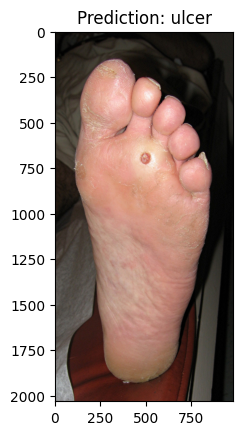

In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# 1. SETUP DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. DEFINE THE ARCHITECTURE (Must match your training)
def get_model():
    model = models.efficientnet_b0(weights=None) # No need for ImageNet weights since we load our own
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 2) 
    )
    return model

# 3. PREPROCESSING (Must match your training transforms)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 4. EXECUTION
# Update these paths!
model_path = r"C:\Users\pc\Downloads\DFU\dfu_model_v1.pth"
image_path = r"C:\Users\pc\Downloads\DFU\Original Images\7.jpg"

if os.path.exists(model_path):
    # Initialize and load
    model = get_model().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Load Image
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.nn.functional.softmax(output, dim=1)
        conf, pred = torch.max(prob, 1)

    # Classes (Ensure order matches your training folders)
    classes = ['healthy', 'ulcer'] 
    
    print(f"Result: {classes[pred.item()]} with {conf.item()*100:.2f}% confidence.")
    
    # Show the image in VS Code
    plt.imshow(img)
    plt.title(f"Prediction: {classes[pred.item()]}")
    plt.show()
else:
    print("Error: Weight file (.pth) not found. Did you save it after training?")